# Machine Learning Assignment 2 - End-to-End Experiment

This notebook is designed to be rerun in the **BITS Virtual Lab**. It prepares the UCI handwritten-digits data, trains all five explicitly listed classifiers, computes the six required metrics, and exports `test_data.csv` plus serialized models.

In [1]:
from pathlib import Path
import json, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, matthews_corrcoef, ConfusionMatrixDisplay, confusion_matrix, classification_report)

SEED = 314
TEST_SIZE = 0.25
print("Environment ready")

Environment ready


## 1. Dataset preparation

UCI Optical Recognition of Handwritten Digits uses 64 integer features representing an 8 x 8 image. The scikit-learn bundled copy used here has 1,797 instances and 10 classes.

In [2]:
digits = load_digits()
feature_names = [f"pixel_{r}_{c}" for r in range(8) for c in range(8)]
X = pd.DataFrame(digits.data, columns=feature_names)
y = pd.Series(digits.target.astype(int), name="target")
print("Shape:", X.shape)
print("Classes:", sorted(y.unique().tolist()))
print("Missing values:", int(X.isna().sum().sum()))
X.head()

Shape: (1797, 64)
Classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Missing values: 0


,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,pixel_1_2,pixel_1_3,pixel_1_4,pixel_1_5,pixel_1_6,pixel_1_7,pixel_2_0,pixel_2_1,pixel_2_2,pixel_2_3,pixel_2_4,pixel_2_5,pixel_2_6,pixel_2_7,pixel_3_0,pixel_3_1,pixel_3_2,pixel_3_3,pixel_3_4,pixel_3_5,pixel_3_6,pixel_3_7,pixel_4_0,pixel_4_1,pixel_4_2,pixel_4_3,pixel_4_4,pixel_4_5,pixel_4_6,pixel_4_7,pixel_5_0,pixel_5_1,pixel_5_2,pixel_5_3,pixel_5_4,pixel_5_5,pixel_5_6,pixel_5_7,pixel_6_0,pixel_6_1,pixel_6_2,pixel_6_3,pixel_6_4,pixel_6_5,pixel_6_6,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,13.0,15.0,10.0,15.0,5.0,0.0,0.0,3.0,15.0,2.0,0.0,11.0,8.0,0.0,0.0,4.0,12.0,0.0,0.0,8.0,8.0,0.0,0.0,5.0,8.0,0.0,0.0,9.0,8.0,0.0,0.0,4.0,11.0,0.0,1.0,12.0,7.0,0.0,0.0,2.0,14.0,5.0,10.0,12.0,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,0.0,11.0,16.0,9.0,0.0,0.0,0.0,0.0,3.0,15.0,16.0,6.0,0.0,0.0,0.0,7.0,15.0,16.0,16.0,2.0,0.0,0.0,0.0,0.0,1.0,16.0,16.0,3.0,0.0,0.0,0.0,0.0,1.0,16.0,16.0,6.0,0.0,0.0,0.0,0.0,1.0,16.0,16.0,6.0,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,3.0,16.0,15.0,14.0,0.0,0.0,0.0,0.0,8.0,13.0,8.0,16.0,0.0,0.0,0.0,0.0,1.0,6.0,15.0,11.0,0.0,0.0,0.0,1.0,8.0,13.0,15.0,1.0,0.0,0.0,0.0,9.0,16.0,16.0,5.0,0.0,0.0,0.0,0.0,3.0,13.0,16.0,16.0,11.0,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,13.0,6.0,15.0,4.0,0.0,0.0,0.0,2.0,1.0,13.0,13.0,0.0,0.0,0.0,0.0,0.0,2.0,15.0,11.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,12.0,12.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,10.0,8.0,0.0,0.0,0.0,8.0,4.0,5.0,14.0,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0,8.0,0.0,0.0,0.0,0.0,0.0,1.0,13.0,6.0,2.0,2.0,0.0,0.0,0.0,7.0,15.0,0.0,9.0,8.0,0.0,0.0,5.0,16.0,10.0,0.0,16.0,6.0,0.0,0.0,4.0,15.0,16.0,13.0,16.0,1.0,0.0,0.0,0.0,0.0,3.0,15.0,10.0,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=SEED, stratify=y
)
print("Train:", X_train.shape, "Test:", X_test.shape)
print(y_test.value_counts().sort_index())

Train: (1347, 64) Test: (450, 64)
target
0    45
1    46
2    44
3    46
4    45
5    46
6    45
7    45
8    43
9    45
Name: count, dtype: int64


## 2. Define the five classifiers

In [4]:
models = {
    "Logistic Regression": Pipeline([("scaler", StandardScaler()), ("classifier", LogisticRegression(max_iter=3000, solver="lbfgs"))]),
    "Decision Tree": DecisionTreeClassifier(random_state=SEED),
    "kNN": Pipeline([("scaler", StandardScaler()), ("classifier", KNeighborsClassifier(n_neighbors=5, weights="distance"))]),
    "Naive Bayes": GaussianNB(),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1, max_features="sqrt"),
}
models

{'Logistic Regression': Pipeline(steps=[('scaler', StandardScaler()),
                 ('classifier', LogisticRegression(max_iter=3000))]),
 'Decision Tree': DecisionTreeClassifier(random_state=314),
 'kNN': Pipeline(steps=[('scaler', StandardScaler()),
                 ('classifier', KNeighborsClassifier(weights='distance'))]),
 'Naive Bayes': GaussianNB(),
 'Random Forest': RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=314)}

## 3. Train and calculate assignment metrics

For the multiclass task, precision/recall/F1 use weighted averaging; AUC uses weighted one-vs-rest.

In [5]:
rows = []
trained = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)
    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "AUC": roc_auc_score(y_test, proba, multi_class="ovr", average="weighted"),
        "Precision": precision_score(y_test, pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_test, pred, average="weighted", zero_division=0),
        "F1": f1_score(y_test, pred, average="weighted", zero_division=0),
        "MCC": matthews_corrcoef(y_test, pred),
    })
    trained[name] = model
metrics_df = pd.DataFrame(rows).set_index("Model")
metrics_df.round(4).sort_values("F1", ascending=False)

,Accuracy,AUC,Precision,Recall,F1,MCC
Model,,,,,,
kNN,0.9822,0.9998,0.9826,0.9822,0.9822,0.9803
Logistic Regression,0.9800,0.9996,0.9804,0.9800,0.9800,0.9778
Random Forest,0.9800,0.9998,0.9802,0.9800,0.9800,0.9778
Naive Bayes,0.8622,0.9805,0.8750,0.8622,0.8623,0.8485
Decision Tree,0.8556,0.9197,0.8602,0.8556,0.8554,0.8401


In [6]:
winner = metrics_df["F1"].idxmax()
print("Overall winner by weighted F1:", winner)

Overall winner by weighted F1: kNN


## 4. Example confusion matrix and classification report

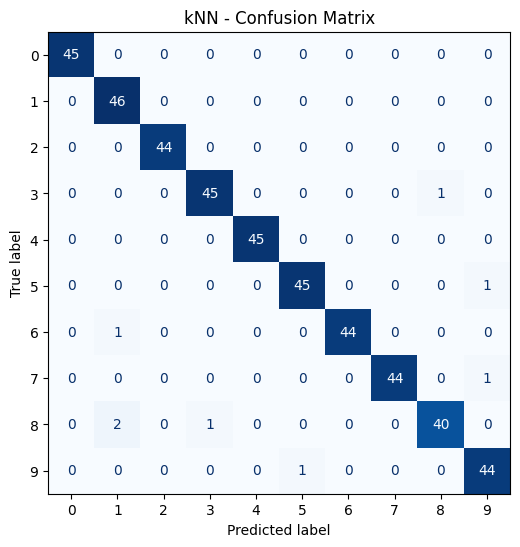

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        45
           1       0.94      1.00      0.97        46
           2       1.00      1.00      1.00        44
           3       0.98      0.98      0.98        46
           4       1.00      1.00      1.00        45
           5       0.98      0.98      0.98        46
           6       1.00      0.98      0.99        45
           7       1.00      0.98      0.99        45
           8       0.98      0.93      0.95        43
           9       0.96      0.98      0.97        45

    accuracy                           0.98       450
   macro avg       0.98      0.98      0.98       450
weighted avg       0.98      0.98      0.98       450



In [7]:
winner_pred = trained[winner].predict(X_test)
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(confusion_matrix(y_test, winner_pred), display_labels=list(range(10))).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"{winner} - Confusion Matrix")
plt.show()
print(classification_report(y_test, winner_pred, zero_division=0))

## 5. Export deployment artifacts

In the repository, `train_models.py` performs this export automatically. The notebook cell below shows the same idea and is useful for a BITS Virtual Lab screenshot.

In [8]:
test_export = X_test.copy()
test_export["target"] = y_test.to_numpy()
print("Rows ready for test_data.csv:", len(test_export))
print("All required modeling steps completed successfully.")

Rows ready for test_data.csv: 450
All required modeling steps completed successfully.
